In [1]:
import pandas as pd
import numpy as np
import torch
import torch.utils.data as data
import torch.nn as nn
import numpy as np
import torch.nn.functional as F
from sklearn.preprocessing import StandardScaler

In [2]:
class RMSLELoss(nn.Module):
    def __init__(self):
        super().__init__()

    def forward(self, y_pred, y_true):
        y_pred = torch.clamp(y_pred, min=0)
        log_pred = torch.log1p(y_pred)
        log_true = torch.log1p(y_true)
        return torch.sqrt(torch.mean((log_pred - log_true) ** 2))

In [3]:
def standarized_data(X_train, X_valid, X_test):
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)  # fit + transform
    X_valid_scaled = scaler.transform(X_valid)  # tylko transform
    X_test_scaled = scaler.transform(X_test)  # tylko transform

    return X_train_scaled, X_valid_scaled, X_test_scaled

Data transformation

In [4]:
df = pd.read_csv("data.csv")


df['mnth'] = df.apply(lambda row: np.sin((row['mnth']-4)*2*np.pi/12), axis=1)
df['hr'] = df.apply(lambda row: np.sin((row['hr']-11)*2*np.pi/24), axis=1)
# df["monthday"] = df.apply(lambda row: int(row["dteday"].split("-")[-1]), axis=1)
df = df.drop(['instant','dteday', 'season'], axis=1)
df

# test_df = pd.read_csv("evaluation_data.csv")


# test_df["mnth"] = test_df.apply(
#     lambda row: np.sin((row["mnth"] - 4) * 2 * np.pi / 12), axis=1
# )
# test_df["hr"] = test_df.apply(
#     lambda row: np.sin((row["hr"] - 11) * 2 * np.pi / 24), axis=1
# )
# # df["monthday"] = df.apply(lambda row: int(row["dteday"].split("-")[-1]), axis=1)
# test_df = test_df.drop(["dteday", "season"], axis=1)
# test_df

,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,0,-1.000000,-2.588190e-01,0,6,0,1,0.24,0.2879,0.81,0.0000,3,13,16
1,0,-1.000000,-5.000000e-01,0,6,0,1,0.22,0.2727,0.80,0.0000,8,32,40
2,0,-1.000000,-7.071068e-01,0,6,0,1,0.22,0.2727,0.80,0.0000,5,27,32
3,0,-1.000000,-8.660254e-01,0,6,0,1,0.24,0.2879,0.75,0.0000,3,10,13
4,0,-1.000000,-9.659258e-01,0,6,0,1,0.24,0.2879,0.75,0.0000,0,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10881,1,-0.866025,8.660254e-01,0,3,1,1,0.38,0.3939,0.50,0.3881,7,329,336
10882,1,-0.866025,7.071068e-01,0,3,1,1,0.36,0.3485,0.57,0.2239,10,231,241
10883,1,-0.866025,5.000000e-01,0,3,1,1,0.34,0.3182,0.61,0.2239,4,164,168
10884,1,-0.866025,2.588190e-01,0,3,1,1,0.34,0.3485,0.61,0.0896,12,117,129


Creating train valid and test dataset and standarizing data (only last column as label)

In [5]:
train = df.sample(frac=0.6, random_state=200)  # random state is a seed value
_rest = df.drop(train.index)
valid = _rest.sample(frac=0.5, random_state=200)  # random state is a seed value
# test = test_df.sample(frac=0.99, random_state=200)
test = _rest.drop(valid.index)
print(f"{train.shape=}")
print(f"{valid.shape=}")
print(f"{test.shape=}")

X_train = train.values[:, :-3]
y_train = train.values[:, -1]

X_valid = valid.values[:, :-3]
y_valid = valid.values[:, -1]

# X_test = test.values[:, :]
X_test = test.values[:, :-3]
y_test = test.values[:, -1]

X_train, X_valid, X_test = standarized_data(X_train, X_valid, X_test)
print(f"{X_train.shape=}")
print(f"{X_valid.shape=}")
print(f"{X_test.shape=}")
print(f"{y_train.shape=}")
print(f"{y_valid.shape=}")
print(f"{y_test.shape=}")

train.shape=(6532, 14)
valid.shape=(2177, 14)
test.shape=(2177, 14)
X_train.shape=(6532, 11)
X_valid.shape=(2177, 11)
X_test.shape=(2177, 11)
y_train.shape=(6532,)
y_valid.shape=(2177,)
y_test.shape=(2177,)


In [6]:
train_dataset = data.TensorDataset(
    torch.from_numpy(X_train).float(),
    torch.from_numpy(y_train).long()
)
valid_dataset = data.TensorDataset(
    torch.from_numpy(X_valid).float(),
    torch.from_numpy(y_valid).long()
)
test_dataset = data.TensorDataset(
    torch.from_numpy(X_test).float(),
    torch.from_numpy(y_test).long()
)

Datasets are now ready
  
---

In [7]:
def create_model(model_class, num_inputs, num_hidden, num_outputs):
    return model_class(num_inputs=num_inputs, num_hidden=num_hidden, num_outputs=num_outputs)

In [51]:
class RegressionModel(nn.Module):

    def __init__(
        self, num_inputs, num_hidden1, num_hidden2, num_outputs=1
    ):
        super().__init__()
        # Initialize the modules we need to build the network
        self.linear1 = nn.Linear(num_inputs, num_hidden1)
        self.act_fn = nn.LeakyReLU()
        # self.norm2 = nn.BatchNorm1d(num_hidden)
        self.linear2 = nn.Linear(num_hidden1, num_hidden2)
        self.linear3 = nn.Linear(num_hidden2, num_outputs)

        # nn.init.xavier_uniform_(self.linear1.weight)
        # nn.init.zeros_(self.linear1.bias)
        # nn.init.xavier_uniform_(self.linear2.weight)
        # nn.init.zeros_(self.linear2.bias)

    def forward(self, x):
        # Perform the calculation of the model to determine the prediction
        x = self.linear1(x)
        x = self.act_fn(x)
        # x = self.norm2(x)
        x = self.linear2(x)
        x = self.act_fn(x)
        x = self.linear3(x)
        return x

In [ ]:
def train_model(model, train_dataset, batch_size, num_epochs, loss_module, optimizer, lr, verbose=0):
    print('--- TRAINING FOR PARAMS ---')
    print(
        f"model architecture:",
        [len(p) for idx, p in enumerate(model.parameters()) if idx % 2 == 0],
    )
    print(f'{model.act_fn=}')
    print(f'{batch_size=}')
    print(f'{num_epochs=}')
    print(f'{lr=}')
    print('-----------')

    train_data_loader = data.DataLoader(
        train_dataset, batch_size=batch_size, shuffle=True
    )

    optimizer = optimizer(model.parameters(), lr=lr)
    model.train()
    losses=[]

    for epoch in range(num_epochs):
        epoch_loss = 0.0
        n_samples= 0
        for data_input, data_label in train_data_loader:
            pred = model(data_input)
            data_label = data_label.view(-1, 1).float()
            loss = loss_module(pred, data_label)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            epoch_loss += loss.item() * batch_size
            n_samples += batch_size

        epoch_loss /= n_samples
        if epoch+1 >= 50:
            losses.append(epoch_loss)
        if verbose > 0 and (epoch+1) % max(1, num_epochs // 10) == 0:
            print(f"Epoch: {epoch+1}, loss: {epoch_loss:.3}")
            evaluate_model(model, valid_dataset, loss_module)

    return model, losses

In [53]:
def evaluate_model(model, test_dataset, loss_module):
    test_data_loader = data.DataLoader(
        test_dataset, batch_size=len(test_dataset), shuffle=False, drop_last=False
    )

    model.eval()  # Set model to eval mode
    loss = 0.0
    size = 0

    with torch.no_grad():  # Deactivate gradients for the following code
        for data_inputs, data_labels in test_data_loader:
            size += 1
            # data_inputs, data_labels = data_inputs.to(device), data_labels.to(device)
            preds = model(data_inputs)
            data_labels = data_labels.view(-1, 1).float()

            loss += loss_module(preds, data_labels).item()

    total_loss = loss / size
    print(f" RMSLE error of the model: {total_loss:4.3f}")

# evaluate_model(model, valid_dataset, LOSS_MODULE)

In [54]:
INPUT_SIZE = next(iter(train_dataset))[0].shape[0]
BATCH_SIZE = 64
LEARNING_RATE_OPTIMIZER = 0.005
OPTIMIZER = torch.optim.Adam
LOSS_MODULE = RMSLELoss()
NUM_EPOCHS = 2000
OUTPUT_SIZE = 1
# HIDDEN_SIZE = 64
HIDDEN_SIZE_1 = 128
HIDDEN_SIZE_2 = 32

# for hs1 in [16, 32, 64]:
#     for hs2 in [16, 32, 64]:
#         for hs3 in [8, 16, 32]
# for hs in [16, 32, 64, 128, 256]:
#     print(f'{hs=}')
# model = RegressionModel(num_inputs=INPUT_SIZE, num_hidden=HIDDEN_SIZE, num_outputs=OUTPUT_SIZE)
model = RegressionModel(
    num_inputs=INPUT_SIZE,
    num_hidden1=HIDDEN_SIZE_1,
    num_hidden2=HIDDEN_SIZE_2,
    num_outputs=OUTPUT_SIZE,
)
_, losses = train_model(model, train_dataset, batch_size=BATCH_SIZE, num_epochs=NUM_EPOCHS, loss_module=LOSS_MODULE, optimizer=OPTIMIZER, lr=LEARNING_RATE_OPTIMIZER, verbose=1)
evaluate_model(model, valid_dataset, LOSS_MODULE)

-- TRAINING FOR PARAMS --
model architecture: [128, 32, 1]
model.act_fn=LeakyReLU(negative_slope=0.01)
batch_size=64
num_epochs=2000
loss_module=RMSLELoss()
lr=0.005
-----------
Epoch: 200, loss: 0.775
 RMSLE error of the model: 0.991
Epoch: 400, loss: 0.678
 RMSLE error of the model: 1.054
Epoch: 600, loss: 0.586
 RMSLE error of the model: 1.105
Epoch: 800, loss: 0.552
 RMSLE error of the model: 1.128
Epoch: 1000, loss: 0.544
 RMSLE error of the model: 1.103
Epoch: 1200, loss: 0.513
 RMSLE error of the model: 1.120
Epoch: 1400, loss: 0.484
 RMSLE error of the model: 1.146
Epoch: 1600, loss: 0.553
 RMSLE error of the model: 1.112
Epoch: 1800, loss: 0.487
 RMSLE error of the model: 1.184
Epoch: 2000, loss: 0.47
 RMSLE error of the model: 1.155
 RMSLE error of the model: 1.155


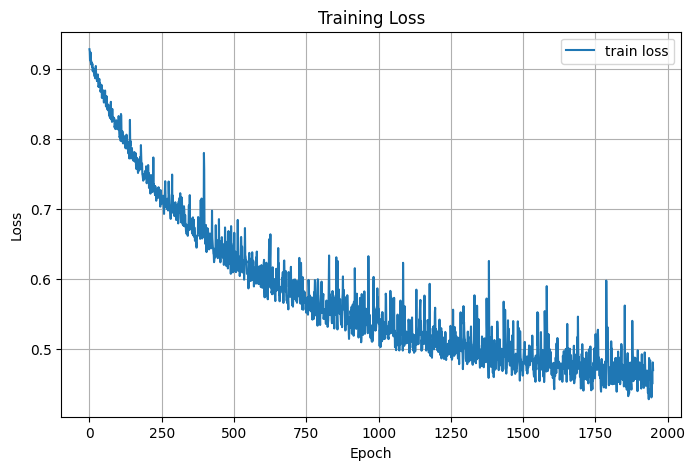

In [57]:
def print_losses(losses):
    import matplotlib.pyplot as plt

    plt.figure(figsize=(8, 5))
    plt.plot(losses, label="train loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    # plt.yscale("log")
    plt.title("Training Loss")
    plt.legend()
    plt.grid(True)

    plt.show()

print_losses(losses)

In [157]:
def generate_predictions(model, dataset, output_file="predictions.csv"):
    loader = data.DataLoader(dataset, batch_size=1, shuffle=False, drop_last=False)

    model.eval()
    preds_list = []

    with torch.no_grad():
        for data_inputs, _ in loader:
            preds = model(data_inputs)

            preds = preds.item()
            preds_list.append(preds)

    pd.Series(preds_list).to_csv(output_file, index=False, header=False)

    print(f"Saved {len(preds_list)} predictions to {output_file}")

In [140]:
model = RegressionModel(num_inputs=INPUT_SIZE, num_hidden=HIDDEN_SIZE, num_outputs=OUTPUT_SIZE)
train_model(
    model,
    train_dataset,
    batch_size=BATCH_SIZE,
    num_epochs=NUM_EPOCHS,
    loss_module=LOSS_MODULE,
    optimizer=OPTIMIZER,
    lr=LEARNING_RATE_OPTIMIZER,
    verbose=0,
)

RegressionModel(
  (linear1): Linear(in_features=11, out_features=64, bias=True)
  (act_fn): ReLU()
  (linear3): Linear(in_features=64, out_features=1, bias=True)
)

In [158]:
generate_predictions(model, train_dataset)

Saved 10777 predictions to predictions.csv
